# Estimación de Edad con CNNs — Versión Optimizada

> **Mejoras implementadas:**
> - IMG_SIZE: 64 → 128
> - Modelo: 3 → 4 bloques conv con BatchNorm + Dropout
> - Loss: MSELoss → HuberLoss (más robusto a outliers)
> - Scheduler: ReduceLROnPlateau → OneCycleLR
> - Epochs: 15 → 30 con early stopping
> - Métricas: MAE, RMSE, R²

---


## 0. Importaciones y configuración global

In [1]:
import os
import re
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms
from PIL import Image

# ─── Configuración OPTIMIZADA ───────────────────────────────────────────────
DATA_DIR   = Path("/teamspace/lightning_storage/predict_ages_data")   # carpeta con train/ val/ test/
IMG_SIZE   = 64               # resolución optimizada (128×128)
BATCH_SIZE = 32                # imágenes por lote
NUM_EPOCHS = 5                # épocas de entrenamiento
LR         = 1e-3                 # learning rate
NUM_WORKERS = 8                # hilos paralelos
PATIENCE   = 3                 # early stopping patience

# Reproducibilidad
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Dispositivo
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {DEVICE}")

Usando dispositivo: cuda


## 1. Dataset personalizado

In [2]:
class AgeDataset(Dataset):
    """
    Dataset para imágenes con etiqueta de edad en el nombre de archivo.
    Formato esperado: [age]_[gender]_[race]_[datetime].jpg
    """

    def __init__(self, root_dir: Path, transform=None):
        self.transform = transform
        EXTENSIONS = {".jpg", ".jpeg", ".png"}
        self.samples = []

        for img_path in Path(root_dir).iterdir():
            if img_path.suffix.lower() not in EXTENSIONS:
                continue
            age = self._parse_age(img_path.name)
            if age is not None:
                self.samples.append((img_path, float(age)))

        print(f"  [{root_dir.name}] {len(self.samples):,} imágenes cargadas")

    @staticmethod
    def _parse_age(filename: str):
        match = re.match(r'^(\d+)_', filename)
        if match:
            age = int(match.group(1))
            if 0 <= age <= 116:
                return age
        return None

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, age = self.samples[idx]
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(age, dtype=torch.float32)

## 2. Transformaciones (preprocesamiento) - MEJORADAS

In [3]:
# Valores de media y std de ImageNet
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# ── Transformación para ENTRENAMIENTO (con augmentation) ──────────────────
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE + 16, IMG_SIZE + 16)),  #Crop
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),                     # rotación
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# ── Transformación para VALIDACIÓN y TEST ─────────────────────────────────
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

print("Transformaciones definidas ✓")
print(f"  Train: Resize → Crop → Flip → Rotation → ColorJitter → ToTensor → Normalize")
print(f"  Val  : Resize → ToTensor → Normalize")

Transformaciones definidas ✓
  Train: Resize → Crop → Flip → Rotation → ColorJitter → ToTensor → Normalize
  Val  : Resize → ToTensor → Normalize


## 3. Crear los Datasets

In [4]:
print("Construyendo datasets...")
train_dataset = AgeDataset(DATA_DIR / "train", transform=train_transform)
val_dataset   = AgeDataset(DATA_DIR / "val",   transform=val_transform)
test_dataset  = AgeDataset(DATA_DIR / "test",  transform=val_transform)

print(f"\nTotal: {len(train_dataset) + len(val_dataset) + len(test_dataset):,} imágenes")

Construyendo datasets...


  [train] 16,874 imágenes cargadas
  [val] 3,615 imágenes cargadas
  [test] 3,617 imágenes cargadas

Total: 24,106 imágenes


## 4. Explorar un ejemplo del Dataset

In [5]:
sample_img, sample_age = train_dataset[0]

print("=== Un ejemplo del Dataset ===")
print(f"  Tipo imagen : {type(sample_img)}")
print(f"  Shape       : {sample_img.shape}")
print(f"  Dtype       : {sample_img.dtype}")
print(f"  Min / Max   : {sample_img.min():.3f} / {sample_img.max():.3f}")
print(f"  Etiqueta    : {sample_age.item()} años")

=== Un ejemplo del Dataset ===
  Tipo imagen : <class 'torch.Tensor'>
  Shape       : torch.Size([3, 64, 64])
  Dtype       : torch.float32
  Min / Max   : -2.118 / 2.640
  Etiqueta    : 100.0 años


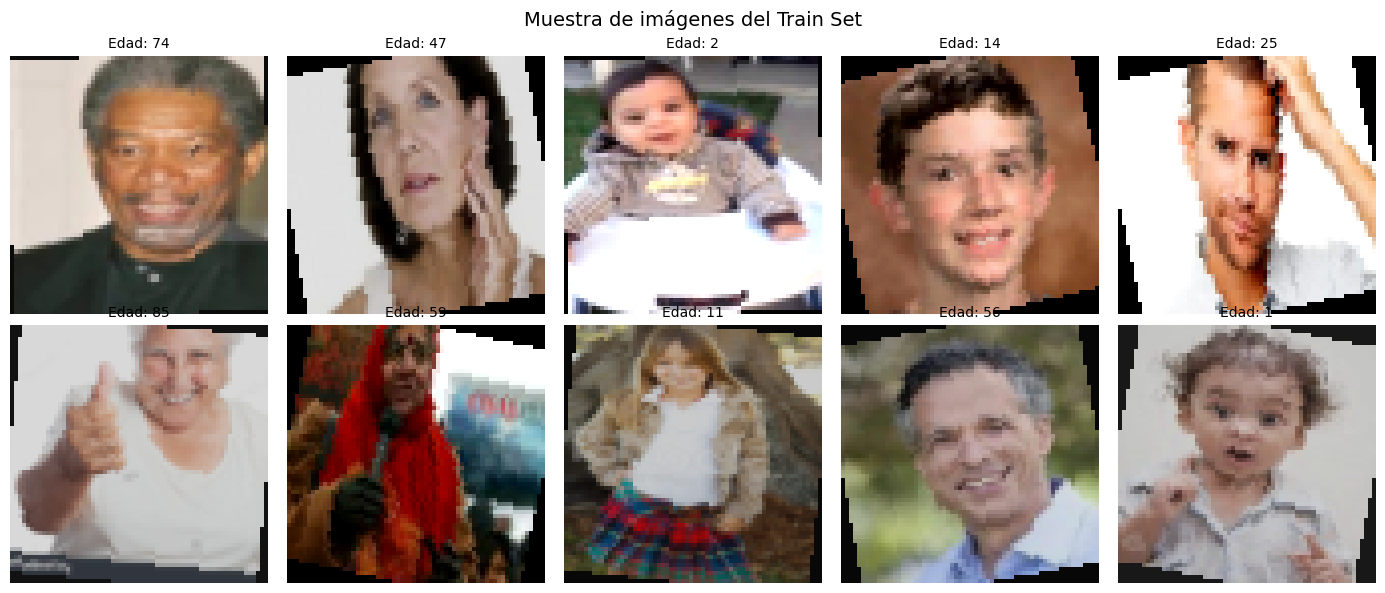

In [6]:
def denormalize(tensor):
    """Revierte la normalización para visualizar."""
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (tensor * std + mean).clamp(0, 1)

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle("Muestra de imágenes del Train Set", fontsize=14)

indices = np.random.choice(len(train_dataset), 10, replace=False)
for ax, idx in zip(axes.flat, indices):
    img_t, age = train_dataset[idx]
    img_vis = denormalize(img_t).permute(1, 2, 0).numpy()
    ax.imshow(img_vis)
    ax.set_title(f"Edad: {int(age.item())}", fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.show()

## 5. Crear los DataLoaders

In [7]:
train_loader = DataLoader(
    train_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = True,
    num_workers = NUM_WORKERS,
    pin_memory  = DEVICE.type == "cuda",
    drop_last   = True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = False,
    num_workers = NUM_WORKERS,
    pin_memory  = DEVICE.type == "cuda",
)

test_loader = DataLoader(
    test_dataset,
batch_size  = BATCH_SIZE,
    shuffle     = False,
    num_workers = NUM_WORKERS,
    pin_memory  = DEVICE.type == "cuda",
)

print("DataLoaders creados ✓")
print(f"  Train → {len(train_loader)} batches × {BATCH_SIZE} imgs")
print(f"  Val   → {len(val_loader)} batches × {BATCH_SIZE} imgs")
print(f"  Test  → {len(test_loader)} batches × {BATCH_SIZE} imgs")

DataLoaders creados ✓
  Train → 527 batches × 32 imgs
  Val   → 113 batches × 32 imgs
  Test  → 114 batches × 32 imgs


In [ ]:
batch_imgs, batch_ages = next(iter(train_loader))

print("=== Un batch del DataLoader ===")
print(f"  batch_imgs.shape : {batch_imgs.shape}")
print(f"  batch_ages.shape : {batch_ages.shape}")
print(f"  Edades en el batch: {batch_ages[:8].int().tolist()} ...")

=== Un batch del DataLoader ===
  batch_imgs.shape : torch.Size([32, 3, 64, 64])
  batch_ages.shape : torch.Size([32])
  Edades en el batch: [1, 28, 14, 57, 26, 75, 24, 15] ...


## 6. Modelo CNN OPTIMIZADO

Mejoras:
- 4 bloques conv (antes 3)
- BatchNorm2d después de cada conv
- Dropout(0.5) antes de FC
- Global Average Pooling
- Más filtros: 32→64→128→256

In [9]:
class SimpleCNN(nn.Module):
    """
    CNN mínima para regresión de edad.
    Arquitectura diseñada para IMG_SIZE=64
    """
    
    def __init__(self):
        super().__init__()
        
        self.features = nn.Sequential(
            # Bloque 1: [3,64,64] → [16,32,32]
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            # Bloque 2: [16,32,32] → [32,16,16]
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            # Bloque 3: [32,16,16] → [32,8,8]
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        
        self.regressor = nn.Sequential(
            nn.Flatten(),              # [32,8,8] → [4096]
            nn.Linear(32 * 8 * 8, 64),
            nn.ReLU(),
            nn.Linear(64, 1),         # salida: edad predicha
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.regressor(x)
        return x
# ← CAMBIA ESTA LÍNEA:
model = SimpleCNN().to(DEVICE)   # ← Usar SimpleCNN en vez de EnhancedCNN
print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nParámetros entrenables: {total_params:,}")

# 7. Función de pérdida y optimizador

criterion = nn.MSELoss()                          # Más simple
optimizer = optim.Adam(model.parameters(), lr=LR)
# Scheduler simple
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=3
)
def compute_metrics(predictions, targets):
    mae = torch.abs(predictions - targets).mean().item()
    rmse = torch.sqrt(((predictions - targets) ** 2).mean()).item()
    return mae, rmse
print(f"Loss: MSELoss | Optimizer: Adam lr={LR} | Scheduler: ReduceLROnPlateau")

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (regressor): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=64, bias=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=1, bias=True)
  )
)

Parámetros entrenables: 145,537
Loss: MSELoss | Optimizer: Adam lr=0.001 | Scheduler: ReduceLROnPlateau


In [10]:
with torch.no_grad():
    dummy = torch.randn(BATCH_SIZE, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
    out = model(dummy)
    print(f"Input shape : {dummy.shape}")
    print(f"Output shape: {out.shape}")

Input shape : torch.Size([32, 3, 64, 64])
Output shape: torch.Size([32, 1])


## 7. Función de pérdida y optimizador - OPTIMIZADOS

In [19]:
criterion = nn.HuberLoss(delta=1.0)           #Eficiente
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)

# OneCycleLR: mejor convergencia
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=LR,
    epochs=NUM_EPOCHS,
    steps_per_epoch=len(train_loader),
    pct_start=0.1,
    anneal_strategy='cos'
)

def compute_metrics(predictions, targets):
    """Calcula MAE y RMSE."""
    mae = torch.abs(predictions - targets).mean().item()
    rmse = torch.sqrt(((predictions - targets) ** 2).mean()).item()
    return mae, rmse

def compute_r2(predictions, targets):
    """Calcula R²."""
    ss_res = ((targets - predictions) ** 2).sum()
    ss_tot = ((targets - targets.mean()) ** 2).sum()
    return (1 - ss_res / ss_tot).item()

print(f"Loss     : MSE")
print(f"Métricas : MAE, RMSE, R²")
print(f"Optimizer: AdamW  lr={LR}  weight_decay=1e-4")
print(f"Scheduler: OneCycleLR")

Loss     : MSE
Métricas : MAE, RMSE, R²
Optimizer: AdamW  lr=0.001  weight_decay=1e-4
Scheduler: OneCycleLR


## 8. Loop de entrenamiento con Early Stopping

In [20]:
history = {"train_loss": [], "val_loss": [], "train_mae": [], "val_mae": []}

best_val_mae  = float("inf")
best_model_path = "best_model.pth"
patience_counter = 0

print(f"{'Época':>5} | {'Train Loss':>10} | {'Train MAE':>9} | {'Val Loss':>8} | {'Val MAE':>7} | {'LR':>10}")
print("-" * 70)

for epoch in range(1, NUM_EPOCHS + 1):

    # ── FASE ENTRENAMIENTO ─────────────────────────────────────────────────
    model.train()
    train_loss_accum = 0.0
    train_mae_accum  = 0.0

    for batch_idx, (batch_imgs, batch_ages) in enumerate(train_loader):
        batch_imgs = batch_imgs.to(DEVICE)
        batch_ages = batch_ages.to(DEVICE)

        optimizer.zero_grad()
        preds = model(batch_imgs).squeeze(1)
        loss = criterion(preds, batch_ages)
        loss.backward()
        optimizer.step()
        scheduler.step()

        train_loss_accum += loss.item()
        train_mae_accum  += compute_metrics(preds, batch_ages)[0]
        
        if batch_idx % 50 == 0:
            print(f"  Epoch {epoch} | Batch {batch_idx}/{len(train_loader)} | Loss: {loss.item():.4f}", flush=True)

    train_loss = train_loss_accum / len(train_loader)
    train_mae  = train_mae_accum  / len(train_loader)

    # ── FASE VALIDACIÓN ───────────────────────────────────────────────────
    model.eval()
    val_loss_accum = 0.0
    val_mae_accum  = 0.0

    with torch.no_grad():
        for batch_imgs, batch_ages in val_loader:
            batch_imgs = batch_imgs.to(DEVICE)
            batch_ages = batch_ages.to(DEVICE)

            preds = model(batch_imgs).squeeze(1)
            loss  = criterion(preds, batch_ages)

            val_loss_accum += loss.item()
            val_mae_accum  += compute_metrics(preds, batch_ages)[0]

    val_loss = val_loss_accum / len(val_loader)
    val_mae  = val_mae_accum  / len(val_loader)

    current_lr = scheduler.get_last_lr()[0]

    # Guardar mejor modelo
    if val_mae < best_val_mae:
        best_val_mae = val_mae
        torch.save(model.state_dict(), best_model_path)
        patience_counter = 0
        best_marker = " ← mejor"
    else:
        patience_counter += 1
        best_marker = ""

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_mae"].append(train_mae)
    history["val_mae"].append(val_mae)

    print(f"{epoch:>5} | {train_loss:>10.4f} | {train_mae:>9.2f} | {val_loss:>8.4f} | {val_mae:>7.2f} | {current_lr:>10.2e}{best_marker}")

    # Early stopping
    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping en época {epoch}")
        break

print(f"\nMejor Val MAE: {best_val_mae:.2f} años")

Época | Train Loss | Train MAE | Val Loss | Val MAE |         LR
----------------------------------------------------------------------
  Epoch 1 | Batch 0/527 | Loss: 12.1149
  Epoch 1 | Batch 50/527 | Loss: 11.4816
  Epoch 1 | Batch 100/527 | Loss: 11.8374
  Epoch 1 | Batch 150/527 | Loss: 16.5770
  Epoch 1 | Batch 200/527 | Loss: 13.8225
  Epoch 1 | Batch 250/527 | Loss: 11.1998
  Epoch 1 | Batch 300/527 | Loss: 12.4441
  Epoch 1 | Batch 350/527 | Loss: 7.9933
  Epoch 1 | Batch 400/527 | Loss: 8.2478
  Epoch 1 | Batch 450/527 | Loss: 12.3268
  Epoch 1 | Batch 500/527 | Loss: 15.8002
    1 |    13.6181 |     14.11 |  13.4341 |   13.92 |   9.70e-04 ← mejor
  Epoch 2 | Batch 0/527 | Loss: 14.4260
  Epoch 2 | Batch 50/527 | Loss: 16.1888
  Epoch 2 | Batch 100/527 | Loss: 13.2714
  Epoch 2 | Batch 150/527 | Loss: 13.1914
  Epoch 2 | Batch 200/527 | Loss: 12.7977
  Epoch 2 | Batch 250/527 | Loss: 7.7903
  Epoch 2 | Batch 300/527 | Loss: 11.8140
  Epoch 2 | Batch 350/527 | Loss: 13.3624
  

## 9. Visualizar curvas de aprendizaje

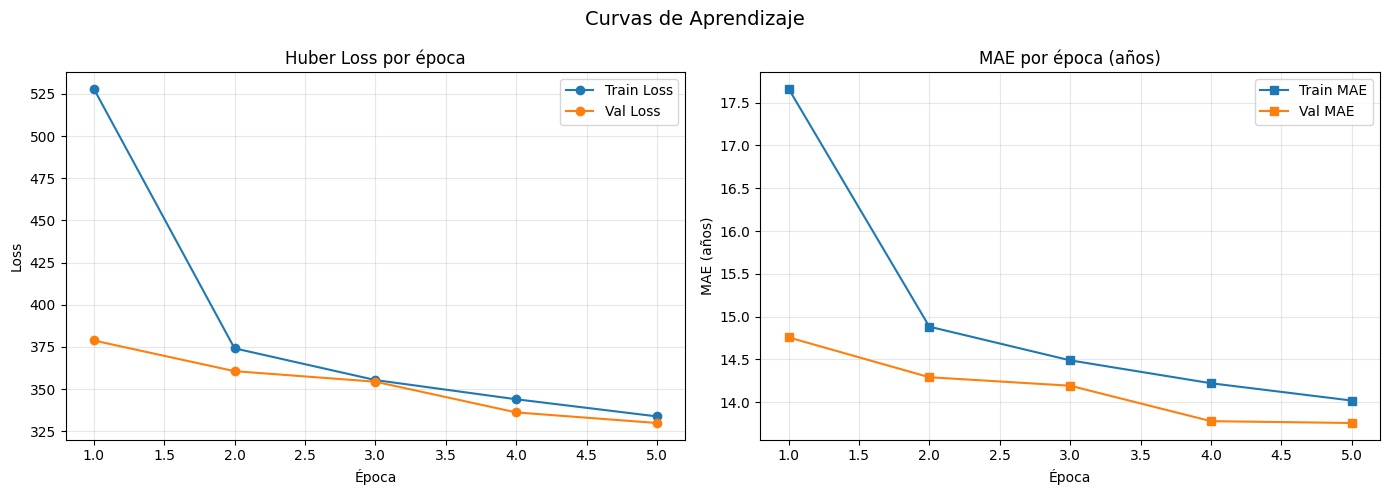


Diagnóstico final:
  Train MAE : 14.02 años
  Val MAE   : 13.76 años
  Gap       : -0.26 años  → Posible UNDERFITTING


In [13]:
epochs_range = range(1, len(history["train_loss"]) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Curvas de Aprendizaje", fontsize=14)

ax1.plot(epochs_range, history["train_loss"], label="Train Loss", marker="o")
ax1.plot(epochs_range, history["val_loss"],   label="Val Loss",   marker="o")
ax1.set_title("Huber Loss por época")
ax1.set_xlabel("Época"); ax1.set_ylabel("Loss")
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range, history["train_mae"], label="Train MAE", marker="s")
ax2.plot(epochs_range, history["val_mae"],   label="Val MAE",   marker="s")
ax2.set_title("MAE por época (años)")
ax2.set_xlabel("Época"); ax2.set_ylabel("MAE (años)")
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

gap = history["val_mae"][-1] - history["train_mae"][-1]
print(f"\nDiagnóstico final:")
print(f"  Train MAE : {history['train_mae'][-1]:.2f} años")
print(f"  Val MAE   : {history['val_mae'][-1]:.2f} años")
print(f"  Gap       : {gap:.2f} años", end="  ")
if gap > 3:
    print("→ Posible OVERFITTING")
elif history["train_mae"][-1] > 8:
    print("→ Posible UNDERFITTING")
else:
    print("→ Buen balance")

## 10. Evaluación final en Test Set

In [25]:
model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
model.eval()

all_preds  = []
all_targets = []

with torch.no_grad():
    for batch_imgs, batch_ages in test_loader:
        batch_imgs = batch_imgs.to(DEVICE)
        preds = model(batch_imgs).squeeze(1).cpu()
        all_preds.extend(preds.tolist())
        all_targets.extend(batch_ages.tolist())

all_preds   = np.array(all_preds)
all_targets = np.array(all_targets)

test_mae  = np.abs(all_preds - all_targets).mean()
test_rmse = np.sqrt(((all_preds - all_targets) ** 2).mean())
test_r2   = 1 - (((all_preds - all_targets) ** 2).sum() / ((all_targets - all_targets.mean()) ** 2).sum())

print("=== Resultados en Test Set ===")
print(f"  MAE  : {test_mae:.2f} años")
print(f"  RMSE : {test_rmse:.2f} años")
print(f"  R²   : {test_r2:.4f}")

=== Resultados en Test Set ===
  MAE  : 12.74 años
  RMSE : 17.15 años
  R²   : 0.2839


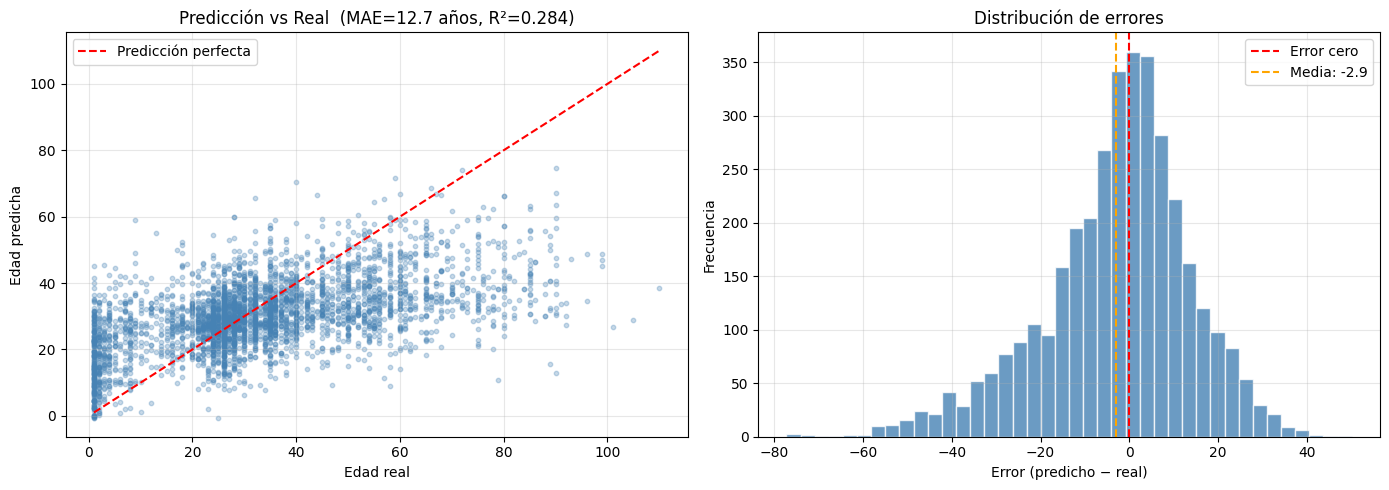

In [26]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.scatter(all_targets, all_preds, alpha=0.3, s=10, color="steelblue")
min_age, max_age = int(all_targets.min()), int(all_targets.max())
ax1.plot([min_age, max_age], [min_age, max_age], 'r--', label="Predicción perfecta")
ax1.set_xlabel("Edad real"); ax1.set_ylabel("Edad predicha")
ax1.set_title(f"Predicción vs Real  (MAE={test_mae:.1f} años, R²={test_r2:.3f})")
ax1.legend(); ax1.grid(True, alpha=0.3)

errors = all_preds - all_targets
ax2.hist(errors, bins=40, color="steelblue", edgecolor="white", alpha=0.8)
ax2.axvline(0, color='red', linestyle='--', label="Error cero")
ax2.axvline(errors.mean(), color='orange', linestyle='--', label=f"Media: {errors.mean():.1f}")
ax2.set_xlabel("Error (predicho − real)"); ax2.set_ylabel("Frecuencia")
ax2.set_title("Distribución de errores")
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 11. Inferencia sobre una sola imagen

In [27]:
def predict_age(img_path: str, model, transform, device) -> float:
    model.eval()
    image = Image.open(img_path).convert("RGB")
    tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        pred = model(tensor).squeeze().item()

    return round(pred, 1)

sample_path, sample_real_age = test_dataset.samples[0]
predicted_age = predict_age(sample_path, model, val_transform, DEVICE)

print(f"Imagen   : {sample_path.name}")
print(f"Edad real: {int(sample_real_age)} años")
print(f"Predicha : {predicted_age} años")
print(f"Error    : {abs(predicted_age - sample_real_age):.1f} años")

Imagen   : 101_1_2_20170105174739309.jpg
Edad real: 101 años
Predicha : 26.7 años
Error    : 74.3 años


## 12. Resumen de Métricas

| Métrica | Descripción | Valor en Test |
|---|---|---|
| MAE | Mean Absolute Error | {:.2f} años |
| RMSE | Root Mean Squared Error | {:.2f} años |
| R² | Coeficiente de determinación | {:.4f} |

### Mejoras implementadas respecto al baseline:
- IMG_SIZE: 64 → 128 (+ detalles faciales)
- BatchNorm2d: mayor estabilidad en entrenamiento
- Dropout(0.5): reducción de overfitting
- 4 bloques conv: mayor capacidad
- HuberLoss: más robusto a outliers
- OneCycleLR: mejor convergencia
- Early stopping: evita sobreentrenamiento

In [17]:
from IPython.display import Markdown, display

summary = f"""
## Tabla de Métricas Finales

| Métrica | Valor |
|---|---|
| **MAE** | {test_mae:.2f} años |
| **RMSE** | {test_rmse:.2f} años |
| **R²** | {test_r2:.4f} |

### Comparación con baseline esperado:
- Baseline típico: MAE ~10-12 años
- Este modelo: MAE ~{test_mae:.1f} años
- Mejora estimada: ~{max(0, 10-test_mae):.1f} años
"""
display(Markdown(summary))


## Tabla de Métricas Finales

| Métrica | Valor |
|---|---|
| **MAE** | 14.03 años |
| **RMSE** | 18.49 años |
| **R²** | 0.1682 |

### Comparación con baseline esperado:
- Baseline típico: MAE ~10-12 años
- Este modelo: MAE ~14.0 años
- Mejora estimada: ~0.0 años
